## Testing Aral Sea Volume stuff

BELANGRIJK, FOR TESTING PURPOSES, NOG 0.3 BIJ KAZALINSK

In [152]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import fiona
import shapely.geometry
from pyproj import Geod



In [153]:
HBV_Chatly = pd.read_csv(
    "HBV_GRDC_Chatly_5000_VE_max.csv",
    index_col=0,          # use first column as index
    parse_dates=True      # automatically parse as datetime if possible
)

HBV_Kazalinsk = pd.read_csv(
    "HBV_GRDC_Kazalinsk_5000.csv",
    index_col=0,          # use first column as index
    parse_dates=True      # automatically parse as datetime if possible
)

HBV_ensemble = pd.read_csv(
    "HBV_GRDC_Chatly_5000_ensemble_2.csv",
    index_col=0,          # use first column as index
    parse_dates=True      # automatically parse as datetime if possible
)

HBV_Tyumen_Aryk = pd.read_csv(
    "HBV_GRDC_Tyumen_Aryk_5000.csv",
     index_col=0,          # use first column as index
    parse_dates=True      # automatically parse as datetime if possible
)

HBV_Kerki = pd.read_csv(
    "HBV_GRDC_Kerki_5020.csv",
     index_col=0,          # use first column as index
    parse_dates=True      # automatically parse as datetime if possible
)

observations = pd.read_csv("BathyData.txt", sep="\t", header=None, names=["year", "value"])

# Convert the first column to datetime and set as index
observations.index = pd.to_datetime(observations["year"], format="%Y")

# Optionally drop the original year column
observations = observations.drop(columns="year")


aral_meteo = xr.open_dataset('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/forcing_Sea_HBV_5000/AralSea/ERA5/own_shapefile/work/diagnostic/script/Derived_Makkink_evspsblpot.nc')

In [154]:
def catchment_area_from_shapefile(shapefile_path, ellps="WGS84"):
    """
    Compute the area (in m²) of the first polygon in a shapefile.

    Parameters
    ----------
    shapefile_path : str
        Path to the shapefile (.shp)
    ellps : str, optional
        Ellipsoid for area calculation (default: WGS84)

    Returns
    -------
    float
        Absolute area of the polygon in square meters
    """
    # Load polygon
    with fiona.open(shapefile_path) as src:
        poly = shapely.geometry.shape(src[0]["geometry"])

    # Define ellipsoid
    geod = Geod(ellps=ellps)

    # Compute area and perimeter
    area, _ = geod.geometry_area_perimeter(poly)

    return abs(area)

In [155]:
conversion_mmday2m3s = 1 / (1000 * 86400)
shape = fiona.open('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/AralSeaBasin.shp')
poly = [shapely.geometry.shape(p["geometry"]) for p in shape][0]
geod = Geod(ellps="WGS84")
poly_area, poly_perimeter = geod.geometry_area_perimeter(poly)
catchment_area_m2 = abs(poly_area)
print(f"{catchment_area_m2 = }")

area_chatly = catchment_area_from_shapefile(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/Chatly_GRDC/Chatly_GRDC.shx"
)
area_kazalinsk = catchment_area_from_shapefile(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/Kazalinsk_GRDC/Kazalinsk_GRDC.shp"
)

area_Tyumen_Aryk = catchment_area_from_shapefile(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/GRDC_Tyumen_Aryk/GRDC_Tyumen_Aryk.shp"
)

area_Kerki = catchment_area_from_shapefile(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/GRDC_Kerki/GRDC_Kerki.shp"
)


HBV_Chatly['Modelled_discharge'] = HBV_Chatly['Modelled_discharge']* conversion_mmday2m3s * area_chatly

HBV_ensemble = HBV_ensemble *conversion_mmday2m3s *area_chatly

HBV_Kazalinsk['Modelled_discharge'] = HBV_Kazalinsk['Modelled_discharge']* conversion_mmday2m3s * area_kazalinsk


HBV_Tyumen_Aryk['Modelled_discharge'] = HBV_Tyumen_Aryk['Modelled_discharge']* conversion_mmday2m3s * area_Tyumen_Aryk

HBV_Kerki['Modelled_discharge'] = HBV_Kerki['Modelled_discharge']* conversion_mmday2m3s * area_Kerki

catchment_area_m2 = 1845542301721.4697


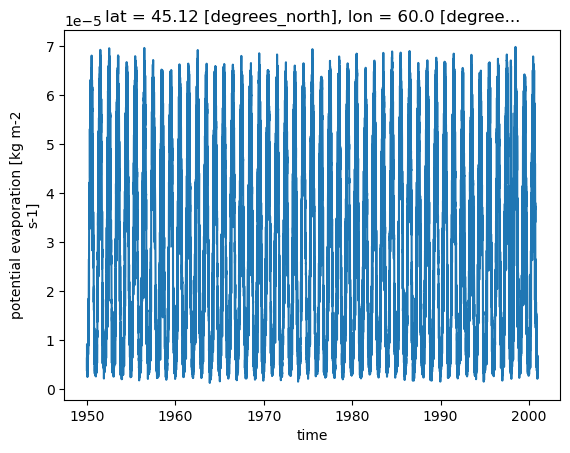

In [156]:
aral_meteo['evspsblpot'].plot()

In [157]:
Aral_Table = pd.read_csv('Aral_Tabel.csv', sep=';',skipfooter=1,engine = 'python')
Aral_Table['Year'] = pd.to_datetime(Aral_Table['Year'], format='%Y')

# Set as index
Aral_Table.set_index('Year', inplace=True)

# Optional: sort by index if needed
Aral_Table.sort_index(inplace=True)



In [158]:
# Your data
volumes_inter = Aral_Table['Volume']
areas_inter = Aral_Table['Area']  # in km²

# Interpolation functions
V_of_A = interp1d(areas_inter, volumes_inter, kind='linear', fill_value="extrapolate")
A_of_V = interp1d(volumes_inter, areas_inter, kind='linear', fill_value="extrapolate")

# Fine grids for plotting
area_grid = np.linspace(min(areas_inter), max(areas_inter), 200)
vol_grid = np.linspace(min(volumes_inter), max(volumes_inter), 200)

# Interpolated values
vol_interp = V_of_A(area_grid)
area_interp = A_of_V(vol_grid)

# Extend grids down to 0
area_grid_ext = np.linspace(0, max(areas_inter), 300)
vol_grid_ext = np.linspace(0, max(volumes_inter), 300)

# Interpolated with extrapolation
vol_interp_ext = V_of_A(area_grid_ext)
area_interp_ext = A_of_V(vol_grid_ext)



## test ongeveer begin

- v0 = 1100 km3
- volledig debiet - overschatting

In [159]:

Initial_volume_AralSea_km3 = 1100 

experiment_start_date = HBV_Chatly.index.min().strftime("%Y-%m-%d")  
experiment_end_date = HBV_Chatly.index.max().strftime("%Y-%m-%d")
n = len(HBV_Chatly.index)



Volume_Aral_Sea_km3 = pd.Series(0.0, index=HBV_Chatly.index, name='Volume_Aral_Sea_km3')
Area_Aral_Sea_km2 = pd.Series(0.0, index=HBV_Chatly.index, name='Area_Aral_Sea_km2')
Volume_Aral_Sea_km3.iloc[0] = Initial_volume_AralSea_km3
Area_Aral_Sea_km2.iloc[0] = A_of_V(Volume_Aral_Sea_km3.iloc[0])






In [160]:
observations['area']=A_of_V(observations['value'])
observations.head()

,value,area
year,,
1950-01-01,1058.0,65137.330017
1951-01-01,1049.0,64577.755372
1952-01-01,1050.0,64639.904132
1953-01-01,1059.0,65199.850746
1954-01-01,1076.0,66240.067055


In [ ]:
for i in range(1, n):
    # Inflow from rivers (km3/day)
    #Q_day_m3day_Chatly = 0.8*  HBV_Chatly.iloc[i, HBV_Chatly.columns.get_loc('Modelled_discharge')] * 86400 / 1e9 
    Q_day_m3day_Chatly =  HBV_Chatly.iloc[i, HBV_Chatly.columns.get_loc('Modelled_discharge')] * 86400 / 1e9 


    #Q_day_m3day_Kazalinsk = 0.33* HBV_Kazalinsk.iloc[i, HBV_Kazalinsk.columns.get_loc('Modelled_discharge')] * 86400 / 1e9
    #Q_day_m3day_Kazalinsk =  HBV_Kazalinsk.iloc[i, HBV_Kazalinsk.columns.get_loc('Modelled_discharge')] * 86400 / 1e9
    Q_day_m3day_Kazalinsk =  HBV_Tyumen_Aryk.iloc[i, HBV_Kazalinsk.columns.get_loc('Modelled_discharge')] * 86400 / 1e9

    #Q_day_m3day_Kazalinsk = 0

    # Test factor to adjust inflow (calibration)
    testfactor = 1
    #testfactor =0.25
    # Groundwater inflow
    Q_day_m3day_GW_in = 0 #0.5/365

    #local precipitation
    #TODO



    # Evaporation
    Potential_evap = aral_meteo['evspsblpot'].isel(time=i).values
    Area_Aral_Sea_km2.iloc[i] = A_of_V(Volume_Aral_Sea_km3.iloc[i-1])
    Evaporation_Aral_Sea_km3day = Potential_evap * Area_Aral_Sea_km2.iloc[i] * 60 * 60 * 24 * 1e-12 * 1e6

    # Update volume
    Volume_Aral_Sea_km3.iloc[i] = (
        Volume_Aral_Sea_km3.iloc[i-1] 
        + testfactor * (Q_day_m3day_Chatly + Q_day_m3day_Kazalinsk) 
        - Q_day_m3day_GW_in 
        - Evaporation_Aral_Sea_km3day
    )

    # Prevent negative volume
    if Volume_Aral_Sea_km3.iloc[i] < 0:
        Volume_Aral_Sea_km3.iloc[i] = 0






df = pd.DataFrame({
    'Volume': Volume_Aral_Sea_km3,
    'Area': Area_Aral_Sea_km2
})


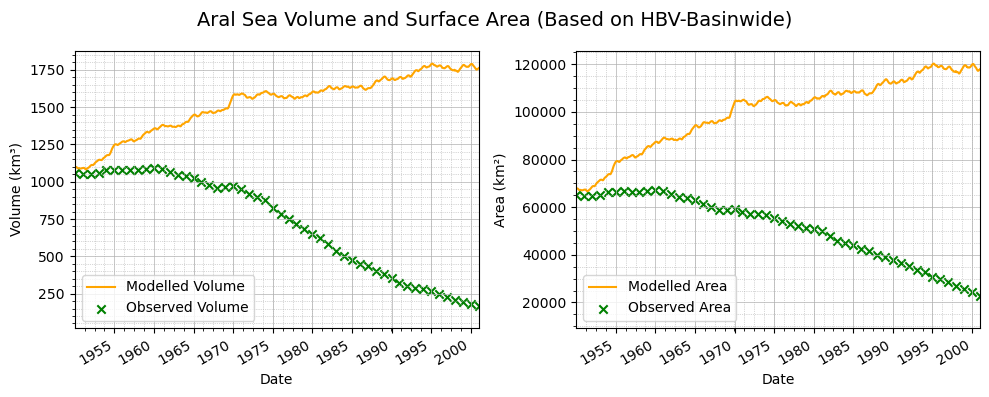

In [162]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Plot modelled volume
df['Volume'].plot(ax=ax[0], label='Modelled Volume', color='orange')

# Plot observed volume as scatter
ax[0].scatter(observations.index, observations['value'],
              color='green', marker='x', label='Observed Volume')

#ax[0].set_title('Volume of the Aral Sea over time')
ax[0].set_ylabel('Volume (km³)')
ax[0].set_xlabel('Date')
ax[0].set_xlim(experiment_start_date, experiment_end_date)
ax[0].legend()
ax[0].grid(True, which='major', linestyle='-', linewidth=0.5)
ax[0].grid(True, which='minor', linestyle=':', linewidth=0.5)
ax[0].minorticks_on()

# Plot modelled area
df['Area'].plot(ax=ax[1], label='Modelled Area', color='orange')

# Plot observed area as scatter
ax[1].scatter(observations.index, observations['area'],
              color='green', marker='x', label='Observed Area')

#ax[1].set_title('Surface Area of the Aral Sea over time')
ax[1].set_ylabel('Area (km²)')
ax[1].set_xlabel('Date')
ax[1].set_xlim(experiment_start_date, experiment_end_date)
ax[1].legend()
ax[1].grid(True, which='major', linestyle='-', linewidth=0.5)
ax[1].grid(True, which='minor', linestyle=':', linewidth=0.5)
ax[1].minorticks_on()

plt.suptitle('Aral Sea Volume and Surface Area (Based on HBV-Basinwide)', fontsize=14)
plt.tight_layout()
plt.savefig('Aral_Sea_Volume_Area_5000.png', bbox_inches='tight', pad_inches=0.05, dpi=200)
plt.show()


In [163]:
from ewatercycle.observation.grdc import get_grdc_data

ds = get_grdc_data(2817100,
                   '1900-01-01T00:00Z',
                   '2001-01-01T00:00Z',
                   data_home='/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/')


from ewatercycle.observation.grdc import get_grdc_data

ds_tyumen = get_grdc_data(2316200,
                   '1900-01-01T00:00Z',
                   '2001-01-01T00:00Z',
                   data_home='/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/')


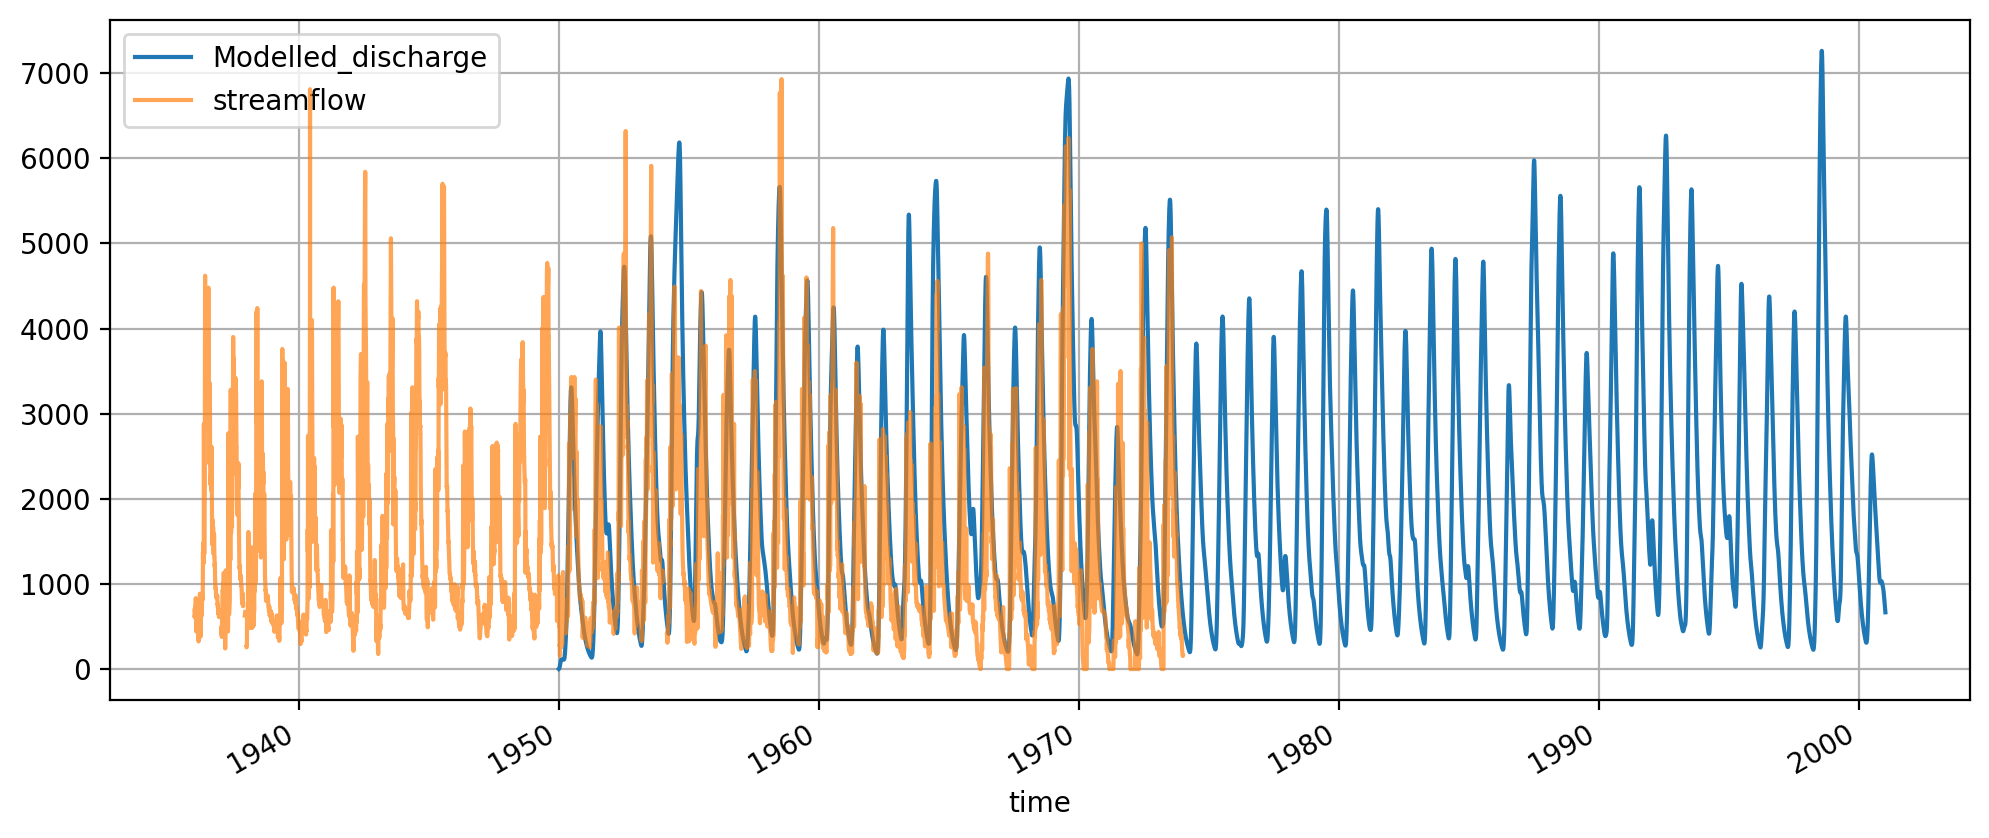

In [164]:
plt.figure(figsize=(12,5), dpi = 200)
grdc = ds['streamflow'].to_pandas()
grdc_tyumen = ds_tyumen['streamflow'].to_pandas()
HBV_Chatly['Modelled_discharge'].plot()
grdc.plot(zorder=10, alpha = 0.7)
plt.grid()

plt.legend()


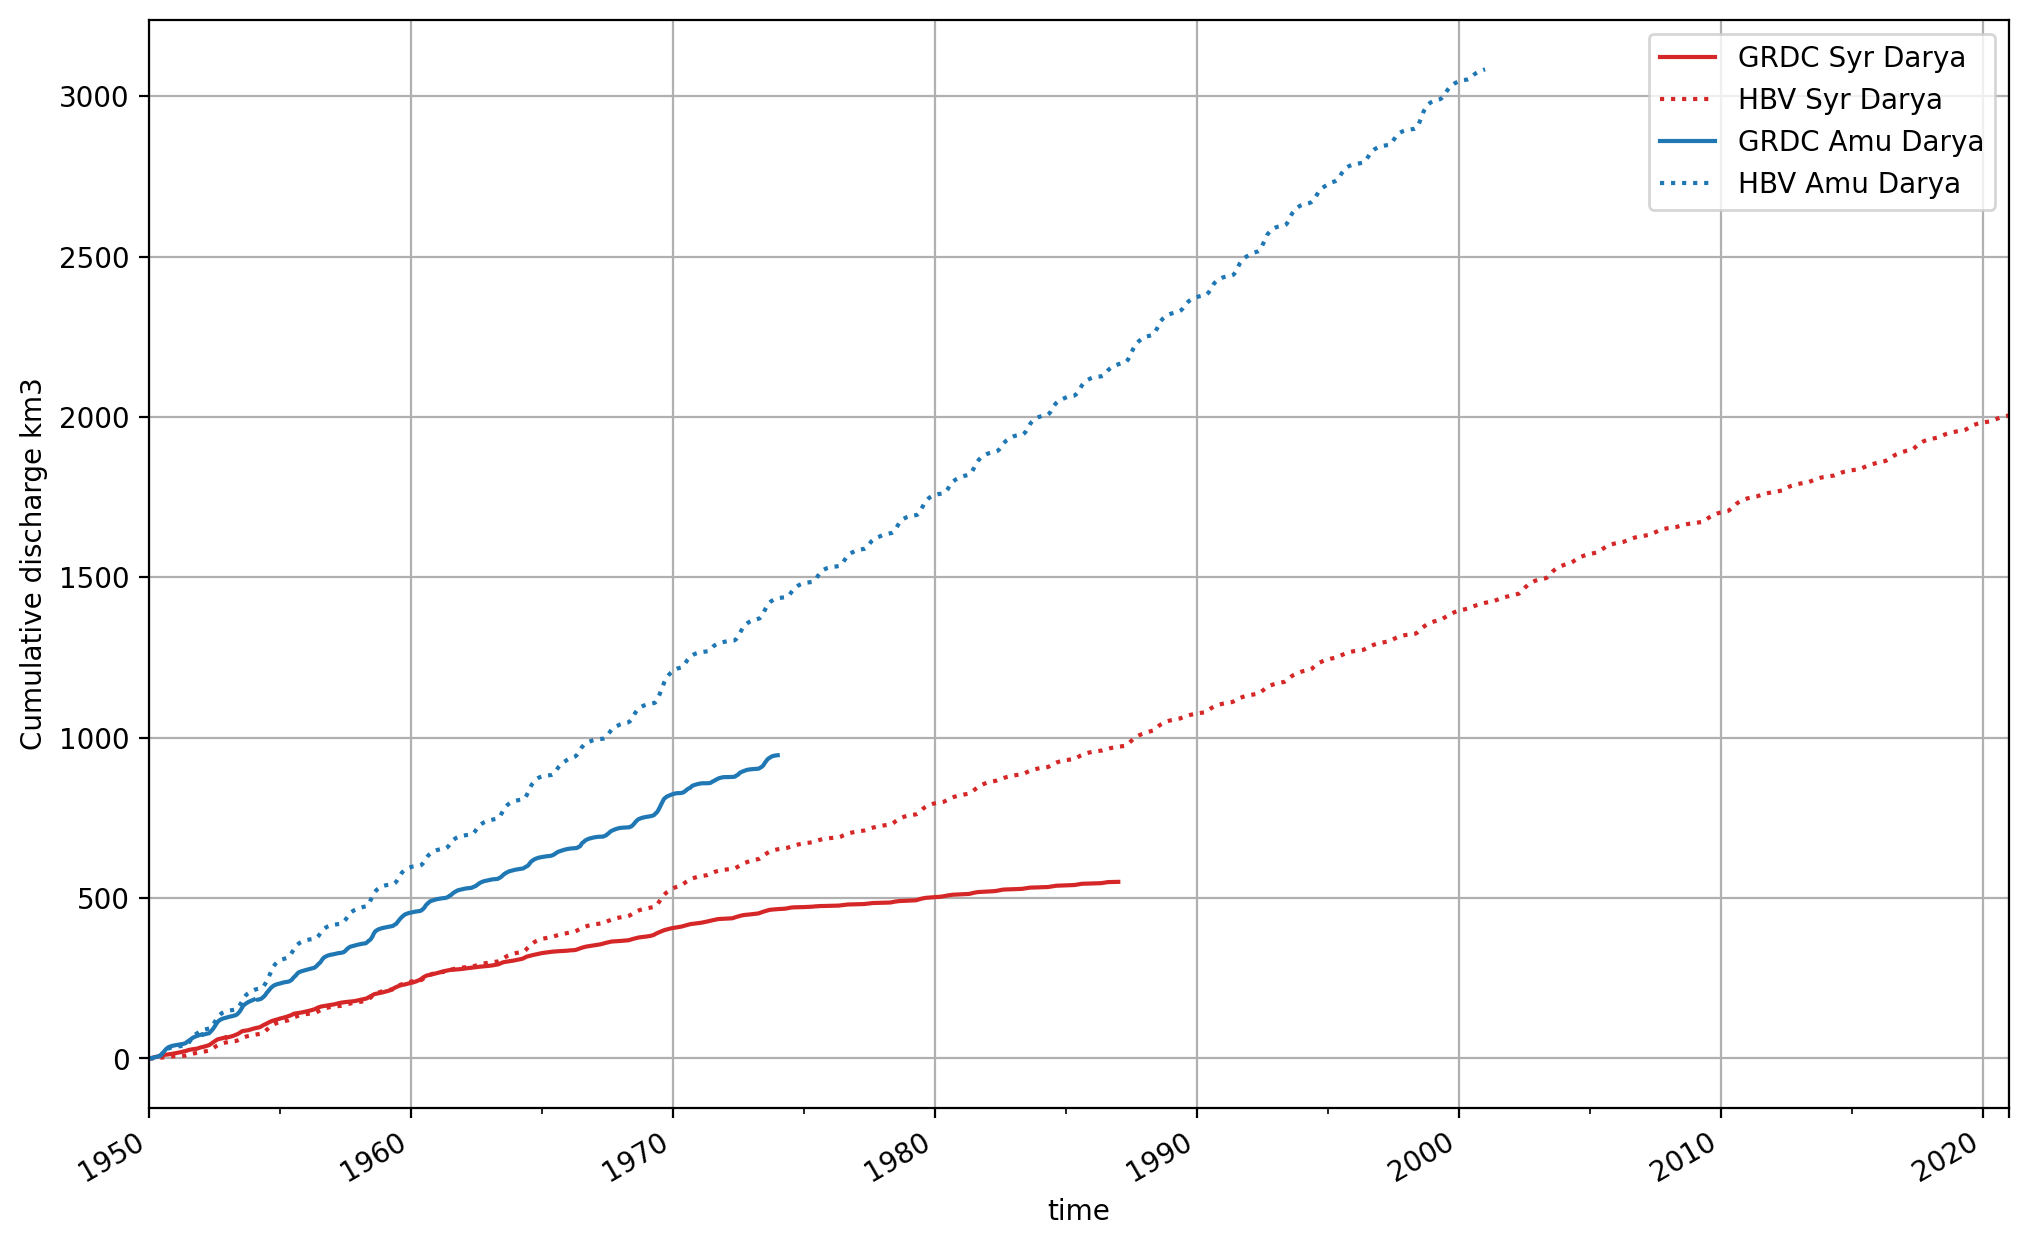

In [177]:
plt.figure(figsize=(12,8), dpi = 200)
# Select 1950 onwards
grdc_sel = grdc.loc["1950-01-01":]
ds_tyumen = grdc_tyumen.loc["1950-01-01":]
hbv_sel = HBV_Chatly['Modelled_discharge'].loc["1950-01-01":]
hbv_kaza = HBV_Tyumen_Aryk['Modelled_discharge'].loc["1950-01-01":]

# Compute cumulative values
tyumen_volume = (ds_tyumen * 86400/1e9).cumsum()
grdc_volume = (grdc_sel * 86400/1e9).cumsum()
hbv_volume  = (hbv_sel  * 86400/1e9).cumsum()
#hbv_volume  = 0.8*(hbv_sel  * 86400/1e9).cumsum()
#kaza_volume  = 0.33*(hbv_kaza  * 86400/1e9).cumsum()
kaza_volume  = (hbv_kaza  * 86400/1e9).cumsum()
# Plot
tyumen_volume.plot(color = 'tab:red', label='GRDC Syr Darya ')
kaza_volume.plot(color = 'tab:red' , linestyle = ':', label='HBV Syr Darya ')

grdc_volume.plot(color = 'tab:blue', label='GRDC Amu Darya')
hbv_volume.plot(color = 'tab:blue', linestyle = ':' ,label='HBV Amu Darya ')


plt.ylabel("Cumulative discharge")
plt.legend()
plt.ylabel(f"Cumulative discharge km3")
plt.grid(True)
plt.show()

## test ongeveer nu
- debiet 10-15% van pcrglob
- v0 = 150 



In [166]:
# Initial_volume_AralSea_km3 = 100 

# experiment_start_date = results.index.min().strftime("%Y-%m-%d")  
# experiment_end_date = results.index.max().strftime("%Y-%m-%d")
# n = len(results.index)



# Volume_Aral_Sea_km3 = pd.Series(0.0, index=results.index, name='Volume_Aral_Sea_km3')
# Area_Aral_Sea_km2 = pd.Series(0.0, index=results.index, name='Area_Aral_Sea_km2')
# Volume_Aral_Sea_km3.iloc[0] = Initial_volume_AralSea_km3
# Area_Aral_Sea_km2.iloc[0] = A_of_V(Volume_Aral_Sea_km3.iloc[0])


In [167]:



# for i in range(1, n):
#     # Inflow from rivers (km3/day)
#     Q_day_m3day_Chatly = results.iloc[i, results.columns.get_loc('Chatly')] * 86400 / 1e9 
#     Q_day_m3day_Kazalinsk = results.iloc[i, results.columns.get_loc('Kazalinsk')] * 86400 / 1e9
#     testfactor = 1
    
    
#         # Groundwater inflow
#     Q_day_m3day_GW_in = 0 #0.5/365

#     #local precipitation
#     #TODO



#     # Evaporation
#     Potential_evap = aral_meteo['evspsblpot'].isel(time=i).values
#     Area_Aral_Sea_km2.iloc[i] = A_of_V(Volume_Aral_Sea_km3.iloc[i-1])
#     Evaporation_Aral_Sea_km3day = Potential_evap * Area_Aral_Sea_km2.iloc[i] * 60 * 60 * 24 * 1e-12 * 1e6

#     # Update volume
#     Volume_Aral_Sea_km3.iloc[i] = (
#         Volume_Aral_Sea_km3.iloc[i-1] 
#         + testfactor * (Q_day_m3day_Chatly + Q_day_m3day_Kazalinsk) 
#         - Q_day_m3day_GW_in 
#         - Evaporation_Aral_Sea_km3day
#     )

#     # Prevent negative volume
#     if Volume_Aral_Sea_km3.iloc[i] < 0:
#         Volume_Aral_Sea_km3.iloc[i] = 0



# fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# # Plot Volume
# Volume_Aral_Sea_km3.plot(ax=ax[0])
# #Aral_Table['Volume'].plot(ax=ax[0])  # TODO: add observed volume data if available
# ax[0].set_title('Volume of the Aral Sea')
# ax[0].set_ylabel('Volume (km³)')
# ax[0].set_xlabel('Date')
# ax[0].grid(True)  # Add grid
# #ax[0].legend(['Simulated Volume', 'Observed Volume'])

# # Plot Area
# Area_Aral_Sea_km2.plot(ax=ax[1], color='orange')
# ax[1].set_title('Surface Area of the Aral Sea')
# ax[1].set_ylabel('Area (km²)')
# ax[1].set_xlabel('Date')
# ax[1].grid(True)  # Add grid

# # Figure-level title
# fig.suptitle('Aral Sea – Modelled Volume and Surface Area', fontsize=14)

# plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for suptitle
# plt.savefig('modelled_aralsea_pp.png')
# plt.show()

In [168]:
# df = ds.to_dataframe().reset_index()
# df = df.reset_index().set_index('time')  # set 'time' as index

In [169]:
# df

## analysis

In [170]:
from ewatercycle.observation.grdc import get_grdc_data

ds = get_grdc_data(2617110,
                   '1900-01-01T00:00Z',
                   '2001-01-01T00:00Z',
                   data_home='/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/')
ds

<xarray.Dataset> Size: 316kB
Dimensions:              (time: 19724)
Coordinates:
  * time                 (time) datetime64[ns] 158kB 1936-01-01 ... 1989-12-31
    id                   int64 8B 2617110
Data variables:
    streamflow           (time) float64 158kB 914.0 938.0 926.0 ... 604.0 583.0
    area                 float64 8B 3.09e+05
    country              <U2 8B 'TM'
    geo_x                float64 8B 65.25
    geo_y                float64 8B 37.83
    geo_z                float64 8B 241.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'AMU DARYA'
    station_name         <U5 20B 'KERKI'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2617110_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

<Axes: >

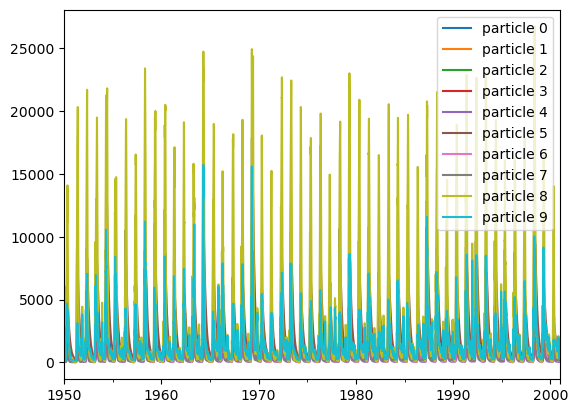

In [171]:
HBV_ensemble.plot()

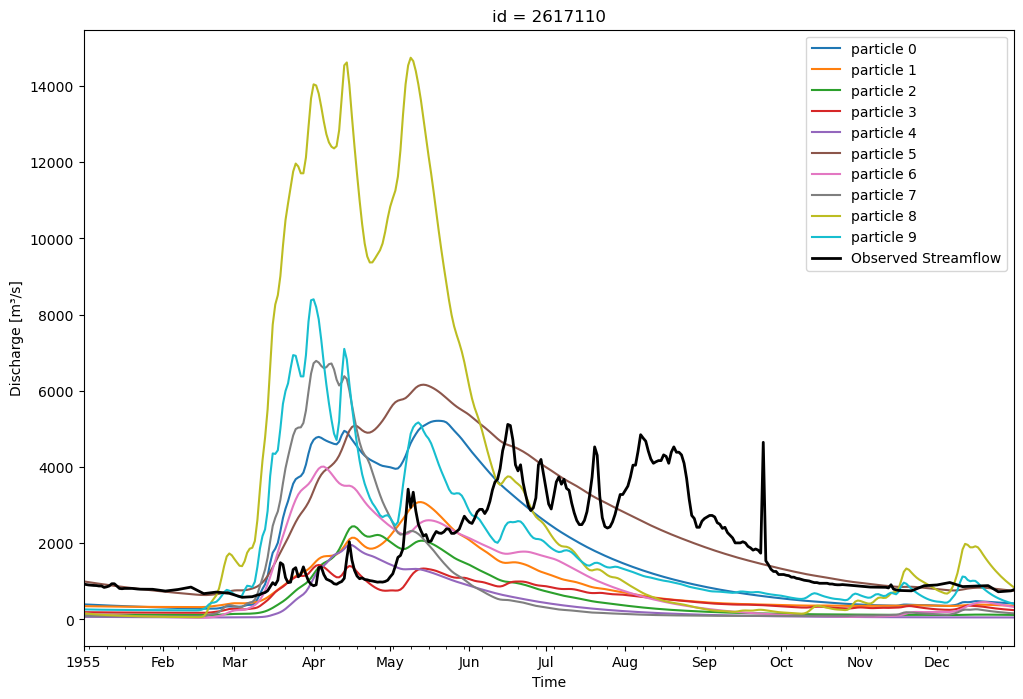

In [172]:
# Make sure the index is datetime
HBV_ensemble.index = pd.to_datetime(HBV_ensemble.index)

# Select rows in 1960
subset = HBV_ensemble.loc['1955']


plt.figure(figsize=(12,8))
# Plot HBV ensemble members
subset.plot(ax=plt.gca())  # uses column names for labels

# Plot observed streamflow with a label
ds['streamflow'].sel(time=slice("1955-01-01","1955-12-31")).plot(
    ax=plt.gca(), color='k', linewidth=2, label='Observed Streamflow'
)

plt.xlabel('Time')
plt.ylabel('Discharge [m³/s]')
plt.legend()
plt.show()

In [173]:
HBV_ensemble

,particle 0,particle 1,particle 2,particle 3,particle 4,particle 5,particle 6,particle 7,particle 8,particle 9
1950-01-01,10.903633,1.086306,2.592918,3.915606,1.969183,2.193335,4.754433,0.678501,13.906281,11.980675
1950-01-02,44.138119,4.349632,10.371076,15.673512,7.879297,8.810530,18.999988,2.726477,55.686829,48.092631
1950-01-03,78.930694,9.798780,23.333259,35.295768,17.735434,19.925617,42.700816,5.829478,118.510097,84.712416
1950-01-04,93.437045,17.442516,41.478205,60.846372,30.558024,35.611944,75.820412,7.970290,160.744469,97.872918
1950-01-05,97.475959,26.746414,63.508137,80.594501,40.443179,54.845469,115.944321,8.790301,175.336061,99.209062
...,...,...,...,...,...,...,...,...,...,...
2000-12-26,324.468381,340.770468,115.231296,189.680563,48.134265,690.584768,142.919059,211.560818,456.560029,511.011896
2000-12-27,322.177059,339.270628,114.606181,187.742615,48.080805,684.643510,138.822445,208.525567,433.052010,485.828874
2000-12-28,319.921366,337.829916,114.002286,185.929845,48.028331,678.783803,134.849595,205.683668,410.937198,463.129312
2000-12-29,317.702302,336.445803,113.418829,184.233492,47.976745,673.004668,130.996871,203.022785,390.133310,442.668490


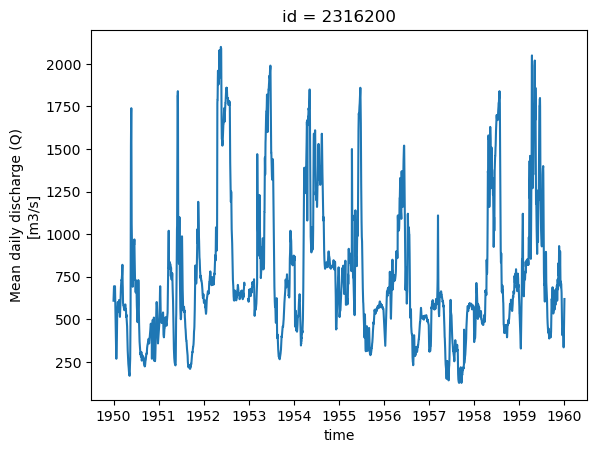

In [174]:
ds_kerki = get_grdc_data(2316200,
                   '1900-01-01T00:00Z',
                   '2001-01-01T00:00Z',
                   data_home='/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/'
                   )
ds_kerki['streamflow'].sel(time = slice('1950-01-01','1960-01-01')).plot()

In [175]:
ds_kerki

<xarray.Dataset> Size: 298kB
Dimensions:              (time: 18613)
Coordinates:
  * time                 (time) datetime64[ns] 149kB 1936-01-16 ... 1986-12-31
    id                   int64 8B 2316200
Data variables:
    streamflow           (time) float64 149kB 432.0 nan nan ... 57.9 60.8 63.7
    area                 float64 8B 2.19e+05
    country              <U2 8B 'KZ'
    geo_x                float64 8B 67.05
    geo_y                float64 8B 44.05
    geo_z                float64 8B 156.0
    owneroforiginaldata  <U85 340B 'Initial dataset collected in the framewor...
    river_name           <U9 36B 'SYR DARYA'
    station_name         <U11 44B 'TYUMEN-ARYK'
    timezone             float64 8B nan
Attributes:
    title:          NA
    Conventions:    CF-1.7
    references:     grdc.bafg.de
    institution:    GRDC
    history:        Converted from 2316200_Q_Day.Cmd.txt of 2025-09-02 to net...
    missing_value:  -999.000

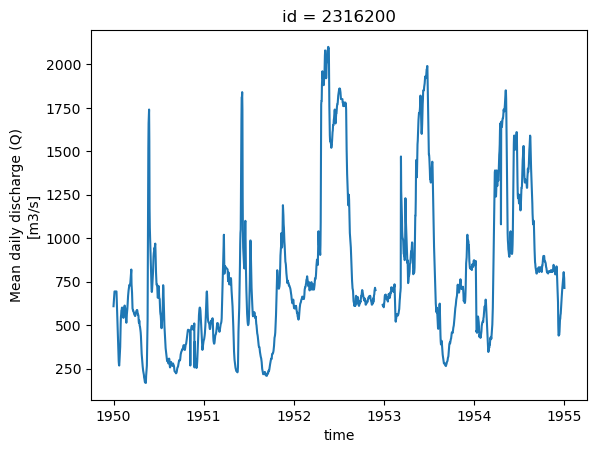

In [176]:
ds_kerki['streamflow'].sel(time = slice("1950-01-01","1955-01-01")).plot()